In [1]:
import logging
# Configuration du logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)

In [2]:
import HBPy
from HBPy.Molecule.Crystal import Crystal,Atom

/home/bulou/venv/ATOMOD/lib/python3.12/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.


In [3]:
 status={
        'abtem':True,
        'feff':True,
        'atomic probability map':True,
        'optimization':False,
    }

config={
   
    'root_dir':'simul',
          'train':{
            'TEM_img_dir':"train/images",  # répertoire de stockage des images TEM
            'prob_maps_img_dir':"train/prob_maps"  # répertoire de stockage des images TEM
        },
 
    'structure':{
         'optimization':status['optimization'],
    'composition':['Pt','Co','Au'],
    'radius':5.0,
    'a':0.5*(3.55+3.92),
    },
     'nvaccum':2.0,
    'image':{
     'xmin':0.0,
     'xmax':0.0,
     'ymin':0.0,
     'ymax':0.0
    },
   'atomic presence probability map':{
            'ninter':{ # nombre d'intervalles entre deux positions atomiques
                'x':20,
                'y':20,
                'z':2
            },
         'sigma': .6  # en Å, largeur de la gaussienne ~ rayon atomique ou un peu moins
   },
            'atomic probability map':{
            'status':status['atomic probability map']
        },
           'abtem':{
            'status':status['abtem'],
            'dx':0.04,
            'dy':0.04,
            'dz':4.08/2,
            'energy':300e3,
            'focal spread':40,
            'semiangle cutoff':20,
            'defocus':200,
            'cell scale':1.1
            },
 }

_______________________________________
# Etape 1 : construire la nanoparticules
 _______________________________________
#   Etape 1.1 : la structure

In [4]:
NP=Crystal()
NP.build(a=config['structure']['a'],
    radius=config['structure']['radius'],
    materials='NP')
NP.origin_at_mass_center()
logger.info(f"min={NP.qmin} max={NP.qmax}")
logger.info(f"Mass center={NP.MC}")
logger.info(f"Number of atoms={len(NP.atoms)}")

2026-06-10 13:12:28,581 [INFO] - <module>() - min=[-4.66875 -4.66875 -4.66875] max=[4.66875 4.66875 4.66875]
2026-06-10 13:12:28,582 [INFO] - <module>() - Mass center=[-1.98830851e-15 -2.50304827e-15 -1.59468398e-15]
2026-06-10 13:12:28,583 [INFO] - <module>() - Number of atoms=44


 #   Etape 1.2 : la distribution chimique   

In [5]:
NP.set_composition(config['structure']['composition'])
NP.save(prefix="NP",fmt='xyz',directory=config['root_dir'])

#   Etape 1.3 : (optionnelle) l'optimisation structurale et/ou chimique

In [6]:
 if config['structure']['optimization']:
     NP.optimize_ase()

 ___________________________________________________________________
# Etape 2 : construire les cartes de probabilité de présence atomique
___________________________________________________________________

2026-06-10 13:12:28,911 [INFO] - xyz2slice() - Number of plane(s) along x: 6
2026-06-10 13:12:28,912 [INFO] - xyz2slice() - Mean interplane distancealong x: 1.8680205205205205
2026-06-10 13:12:28,913 [INFO] - xyz2slice() -  [-1.30130130e-03  1.87125876e+00  3.73246997e+00  5.60503003e+00
  7.46624124e+00  9.33880130e+00]
2026-06-10 13:12:29,154 [INFO] - xyz2slice() - Number of plane(s) along y: 6
2026-06-10 13:12:29,155 [INFO] - xyz2slice() - Mean interplane distancealong y: 1.8680205205205205
2026-06-10 13:12:29,156 [INFO] - xyz2slice() -  [-1.30130130e-03  1.87125876e+00  3.73246997e+00  5.60503003e+00
  7.46624124e+00  9.33880130e+00]
2026-06-10 13:12:29,391 [INFO] - xyz2slice() - Number of plane(s) along z: 6
2026-06-10 13:12:29,391 [INFO] - xyz2slice() - Mean interplane distancealong z: 1.8680205205205205
2026-06-10 13:12:29,392 [INFO] - xyz2slice() -  [-1.30130130e-03  1.87125876e+00  3.73246997e+00  5.60503003e+00
  7.46624124e+00  9.33880130e+00]
2026-06-10 13:12:29,393 [INFO] 

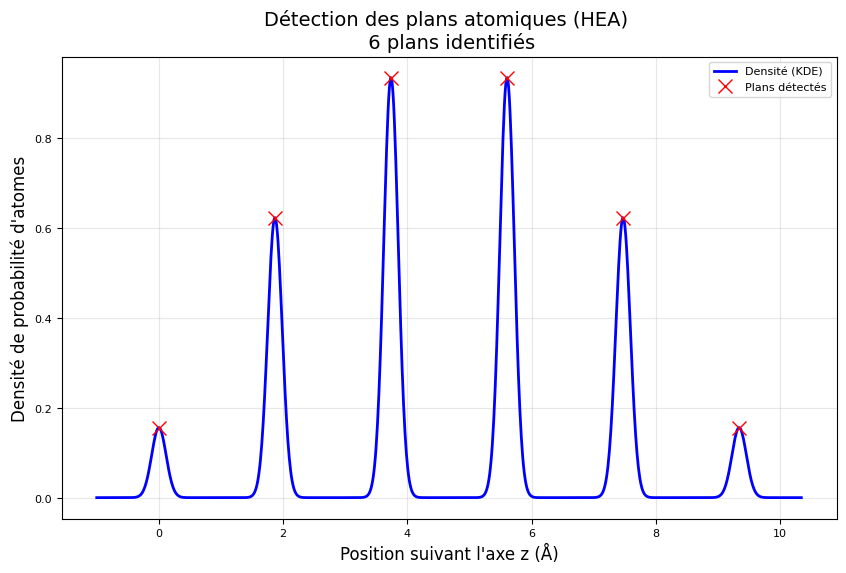

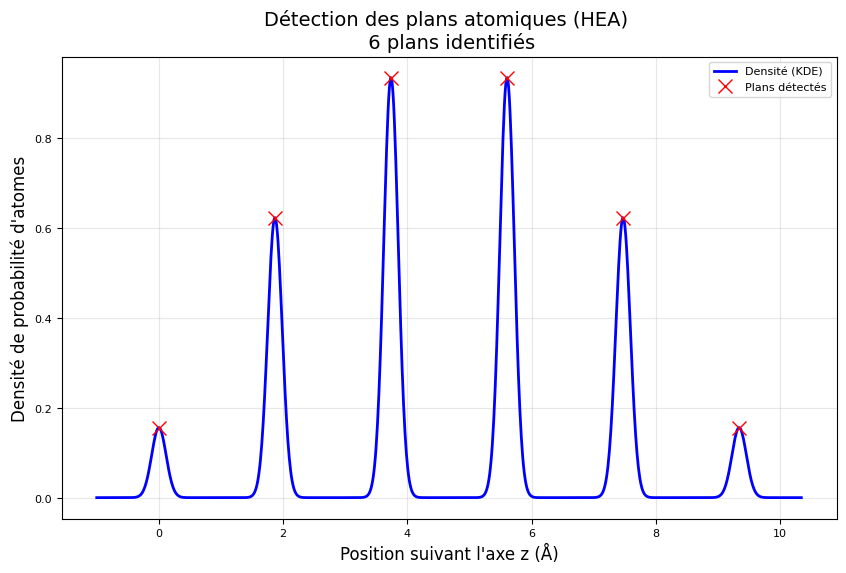

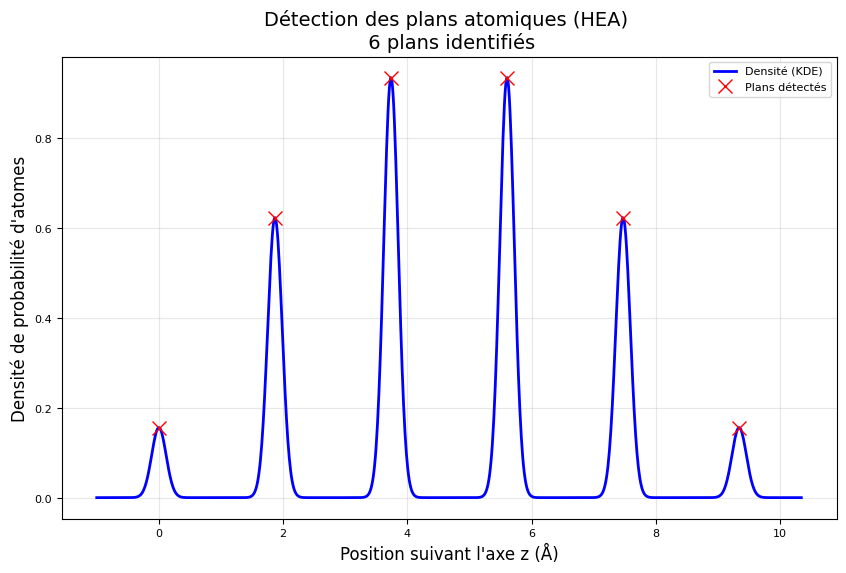

In [7]:
 if config['atomic probability map']['status']:
     NP.xyz2slice(config)
     logger.info(f"{NP.qmin[0]} {NP.qmax[0]} {NP.qmin[1]} {NP.qmax[1]}")
     logger.info(f"{config['image']['xmin']} {config['image']['xmax']} {config['image']['ymin']} {config['image']['ymax']}")


___________________________________________________________________
# Etape 3 : construire l'image TEM
    abTEM : https://github.com/abTEM/abTEM
    https://abtem.readthedocs.io/en/latest/intro.html
___________________________________________________________________
   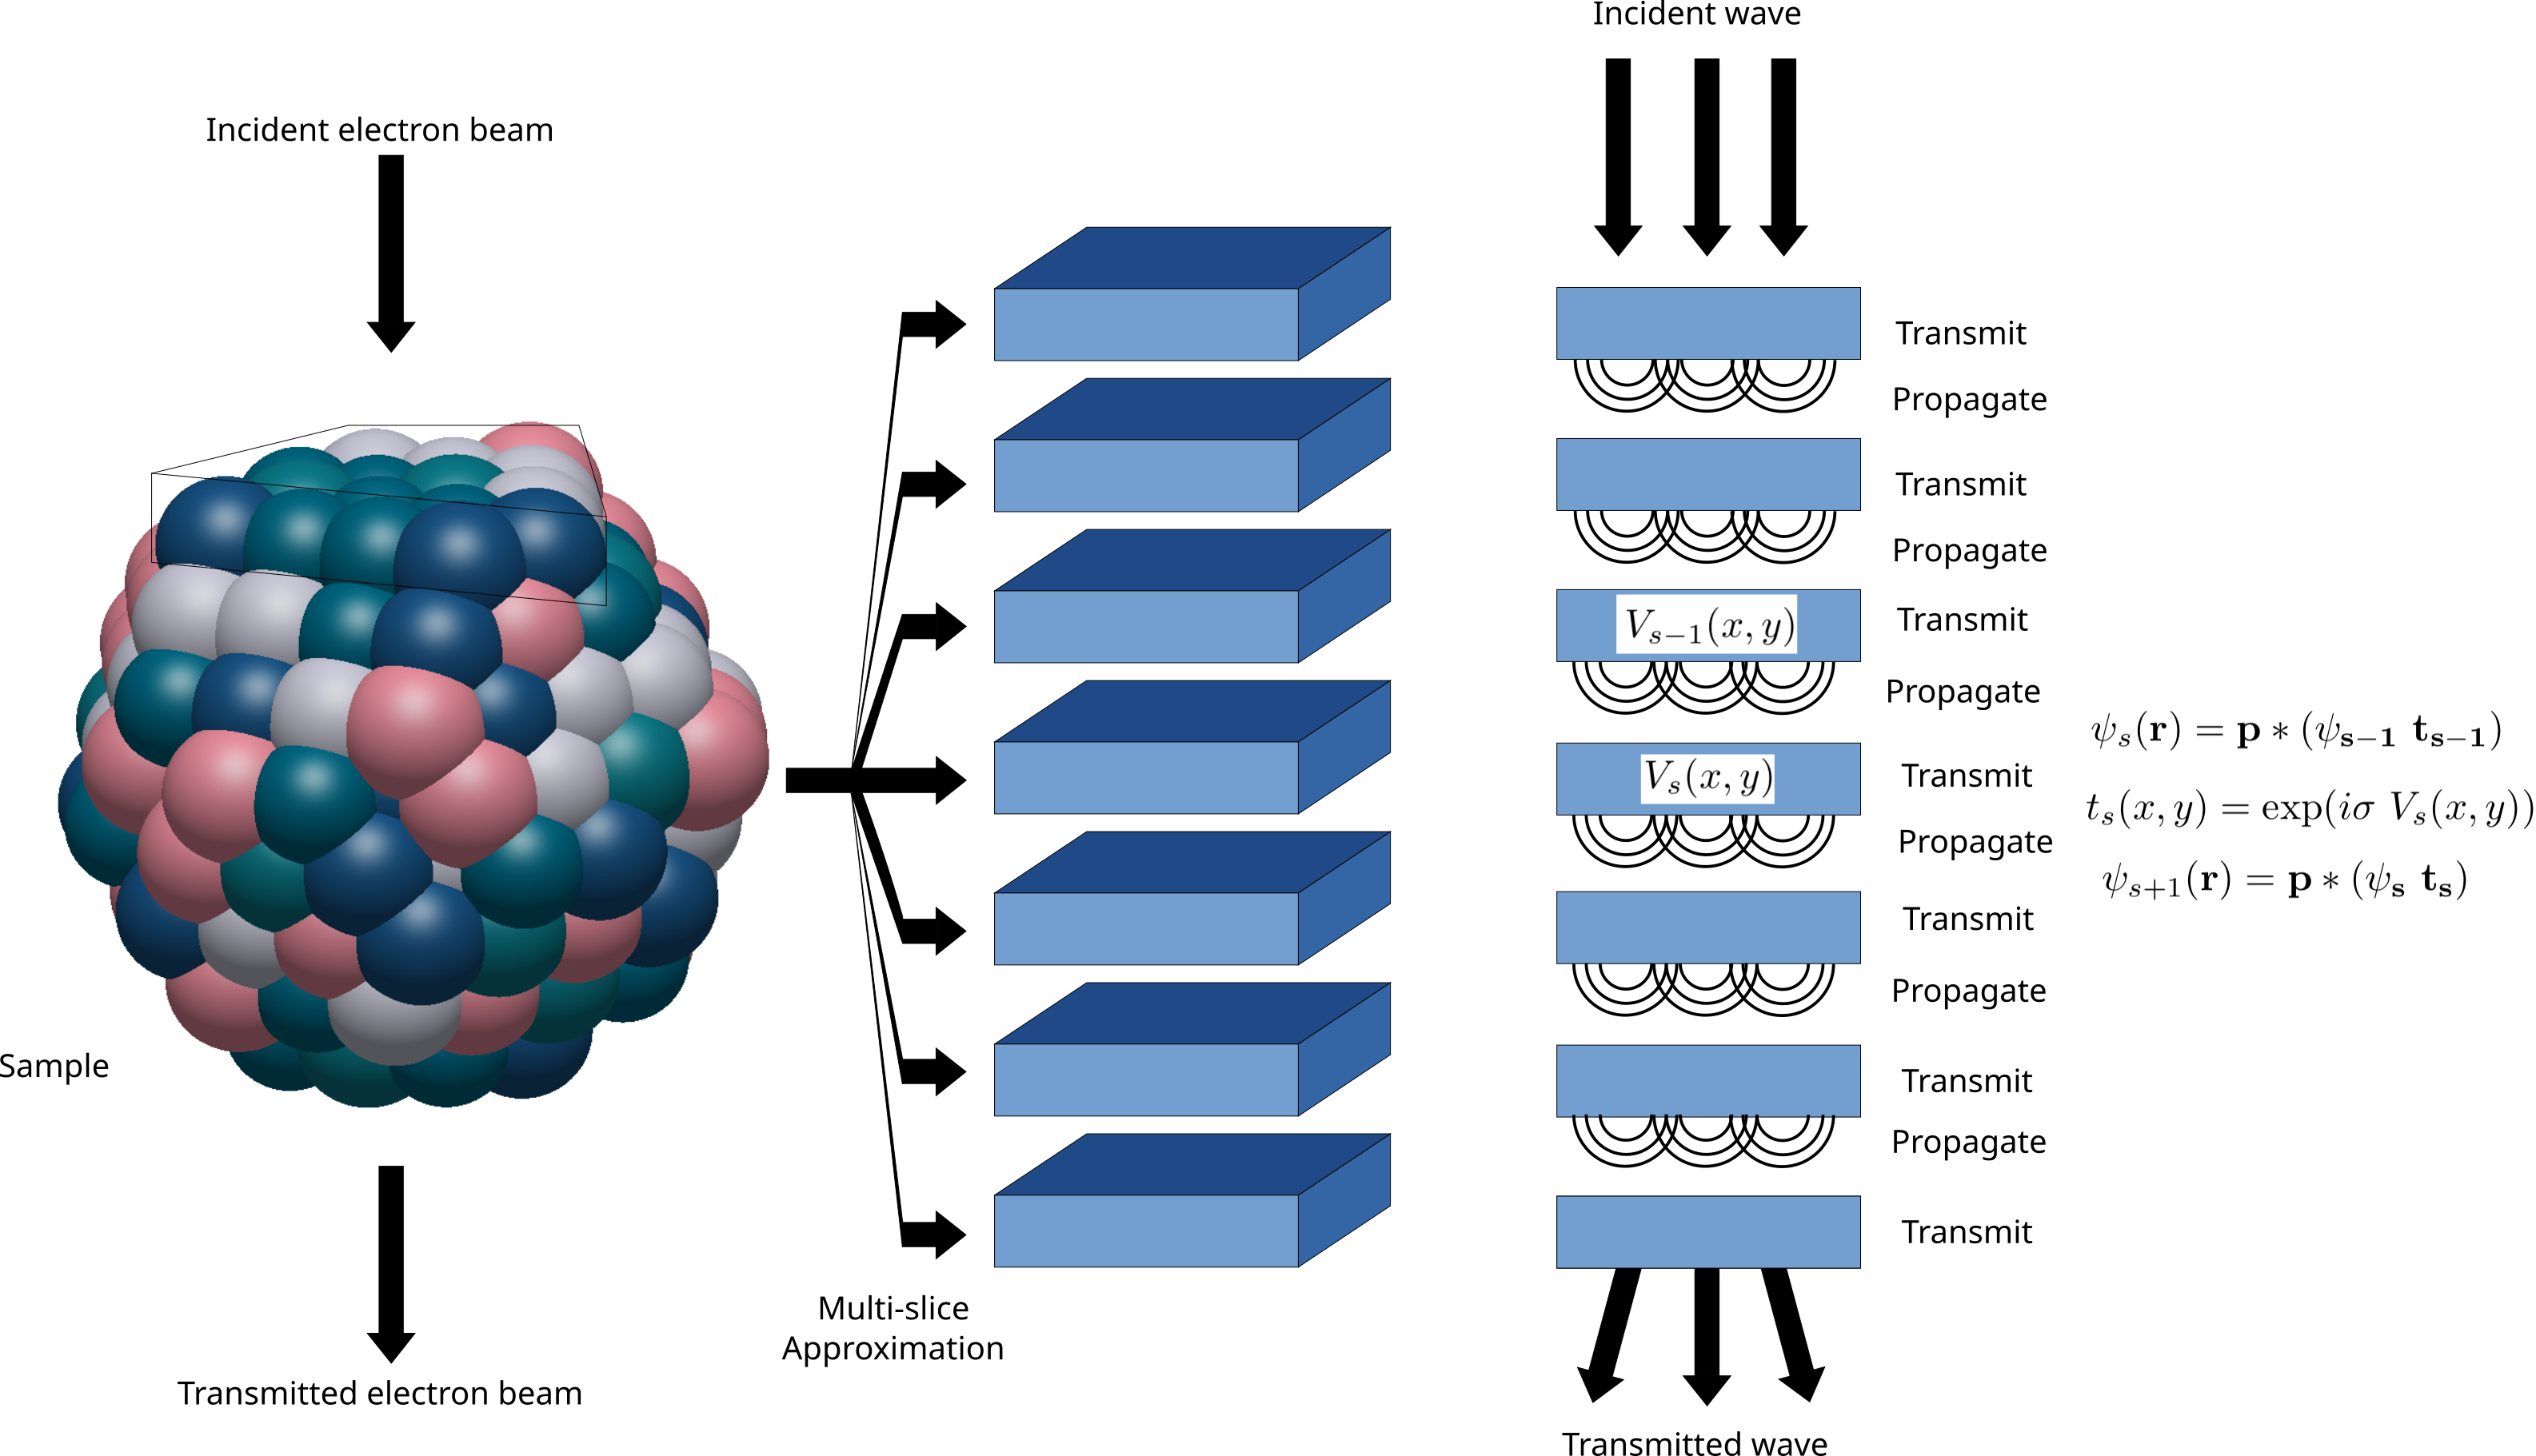


2026-06-10 13:12:35,834 [INFO] - abTEM() - TEM images directory = simul/train/images
2026-06-10 13:12:35,835 [INFO] - abTEM() - Cell size: 16.80958208208208
2026-06-10 13:12:35,840 [INFO] - abTEM() - slice_thickness= 2.04  sampling=0.04
2026-06-10 13:12:35,843 [INFO] - abTEM() - potential extansion: (16.80958208208208, 16.80958208208208)
2026-06-10 13:12:35,844 [INFO] - abTEM() - potential origin: (0.0, 0.0, 0.0)
2026-06-10 13:12:35,844 [INFO] - abTEM() - potential shape: (9, 421, 421)


[########################################] | 100% Completed | 3.64 ss


2026-06-10 13:12:39,690 [INFO] - abTEM() - sampling=(0.039927748413496625, 0.039927748413496625)
2026-06-10 13:12:39,691 [INFO] - abTEM() - extent=(16.80958208208208, 16.80958208208208)
2026-06-10 13:12:39,691 [INFO] - abTEM() - gpts=(421, 421)


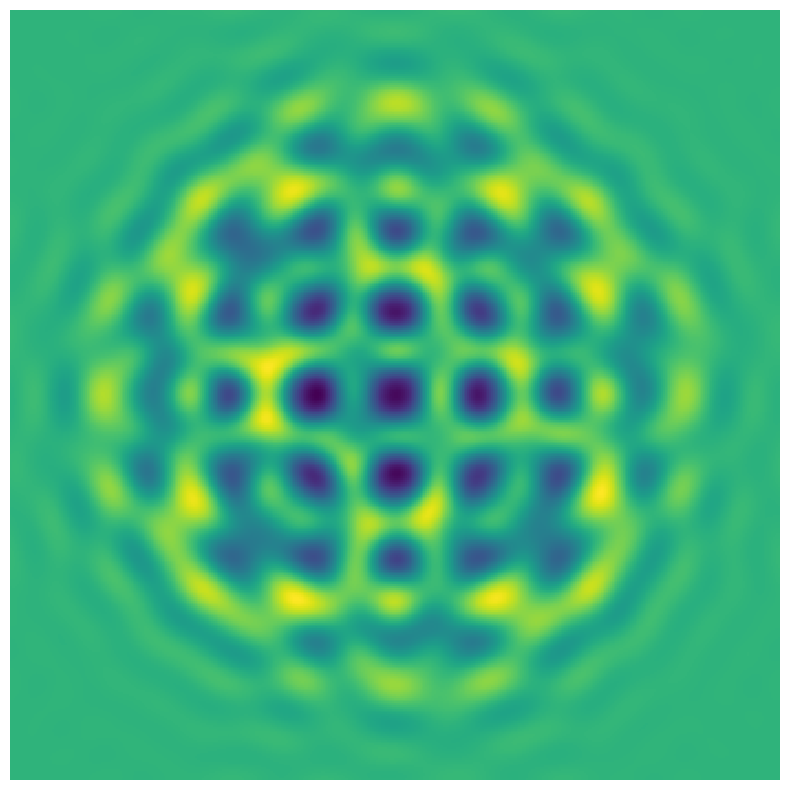

In [8]:
if config['abtem']['status']:
        NP.abTEM(config)
